In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [73]:
df = pd.read_csv("/content/student_placement_ann_dataset.csv")

In [74]:
df.head()

,CGPA,Aptitude_Score,Communication_Score,Internships,Projects,Attendance_Percentage,Placed
0,8.48,35,88,1,4,60,1
1,6.97,53,64,2,0,83,1
2,8.86,66,95,3,1,90,0
3,8.14,91,81,1,2,82,1
4,5.42,80,74,0,3,75,1


In [75]:
df.shape

(400, 7)

In [76]:
df.isnull().sum()

,0
CGPA,0
Aptitude_Score,0
Communication_Score,0
Internships,0
Projects,0
Attendance_Percentage,0
Placed,0


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CGPA                   400 non-null    float64
 1   Aptitude_Score         400 non-null    int64  
 2   Communication_Score    400 non-null    int64  
 3   Internships            400 non-null    int64  
 4   Projects               400 non-null    int64  
 5   Attendance_Percentage  400 non-null    int64  
 6   Placed                 400 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 22.0 KB


In [78]:
df.describe()

,CGPA,Aptitude_Score,Communication_Score,Internships,Projects,Attendance_Percentage,Placed
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.234475,64.930000,65.000000,1.455000,2.012500,79.910000,0.945000
std,1.282255,17.603118,17.983423,1.138515,1.399013,12.057377,0.228266
min,5.030000,35.000000,35.000000,0.000000,0.000000,60.000000,0.000000
25%,6.077500,50.000000,50.000000,0.000000,1.000000,69.000000,1.000000
50%,7.210000,66.000000,64.500000,1.000000,2.000000,79.000000,1.000000
75%,8.410000,80.000000,81.000000,2.000000,3.000000,91.000000,1.000000
max,9.470000,95.000000,95.000000,3.000000,4.000000,100.000000,1.000000


In [79]:
x = df.drop(columns=["Placed"], axis=1)
y = df["Placed"]

In [80]:
x.shape, y.shape

((400, 6), (400,))

In [81]:
#Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [83]:
#Import ANN liberies from tenserflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [84]:
model = Sequential()

In [85]:
model.add(Dense(12, activation="relu", input_shape= (6,)))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197 (788.00 B)

 Trainable params: 197 (788.00 B)

 Non-trainable params: 0 (0.00 B)

In [87]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [88]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8924 - loss: 0.4982 - val_accuracy: 0.9062 - val_loss: 0.4359
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9479 - loss: 0.4220 - val_accuracy: 0.9688 - val_loss: 0.3606
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9514 - loss: 0.3619 - val_accuracy: 0.9688 - val_loss: 0.3010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9514 - loss: 0.3152 - val_accuracy: 0.9688 - val_loss: 0.2532
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9514 - loss: 0.2786 - val_accuracy: 0.9688 - val_loss: 0.2176
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9514 - loss: 0.2519 - val_accuracy: 0.9688 - val_loss: 0.1906
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9514 - loss: 0.2337 - val_accuracy: 0.9688 - val_loss: 0.1710
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9514 - loss: 0.2202 - val_accuracy: 0.9688 - val_loss

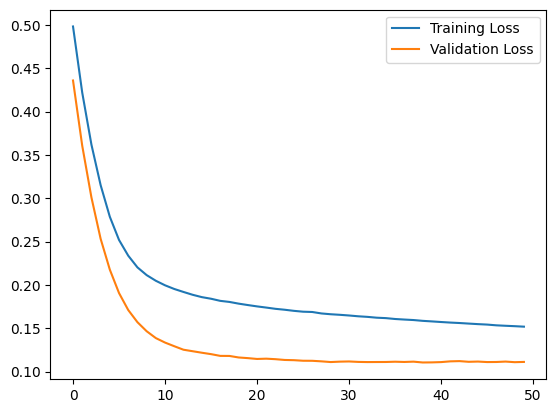

In [89]:
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.legend()
plt.show()

In [90]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9125 - loss: 0.3511 
Test Loss: 0.3510802388191223
Test Accuracy: 0.9125000238418579


In [91]:
predictions = model.predict(x_test)

print(predictions)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.93317217]
 [0.94178444]
 [0.95263803]
 [0.99617606]
 [0.9539715 ]
 [0.9908655 ]
 [0.9598894 ]
 [0.985928  ]
 [0.9288328 ]
 [0.97600406]
 [0.98971   ]
 [0.85701615]
 [0.8537971 ]
 [0.8886386 ]
 [0.99858457]
 [0.97267467]
 [0.81524223]
 [0.98801535]
 [0.77667934]
 [0.95572376]
 [0.9854665 ]
 [0.94200325]
 [0.9817685 ]
 [0.88350445]
 [0.9968042 ]
 [0.94831604]
 [0.7482577 ]
 [0.9651762 ]
 [0.9709437 ]
 [0.9801903 ]
 [0.95365316]
 [0.99221283]
 [0.92502475]
 [0.91563356]
 [0.96461916]
 [0.97557276]
 [0.9944881 ]
 [0.9504783 ]
 [0.98222345]
 [0.9773264 ]
 [0.93998903]
 [0.9711154 ]
 [0.934713  ]
 [0.9951625 ]
 [0.9966455 ]
 [0.9631096 ]
 [0.91021115]
 [0.9942613 ]
 [0.96597457]
 [0.99763185]
 [0.96034926]
 [0.81752485]
 [0.9852766 ]
 [0.9573664 ]
 [0.9447933 ]
 [0.9961222 ]
 [0.91783935]
 [0.98935187]
 [0.96217793]
 [0.91375434]
 [0.9228917 ]
 [0.93574935]
 [0.9950552 ]
 [0.9573889 ]
 [0.95460546]
 [0.9762947 ]
 [0.9930227 ]
 [0.8613256 ]
 [0.979105

In [92]:
predicted_classes = (predictions >= 0.5).astype(int)

print(predicted_classes)

[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]


In [93]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predicted_classes.flatten()
})

result

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
75,1,1
76,1,1
77,1,1
78,1,1


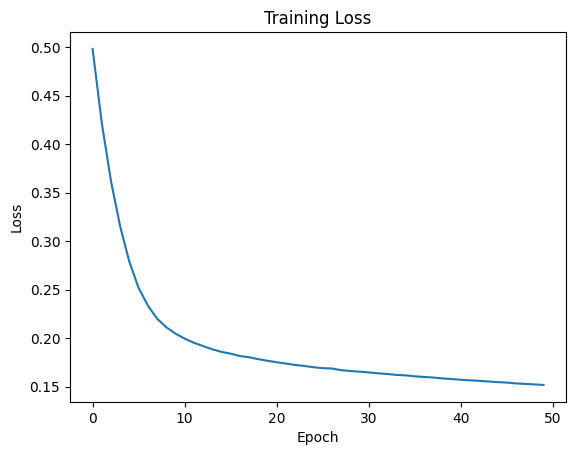

In [94]:
plt.plot(history.history["loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

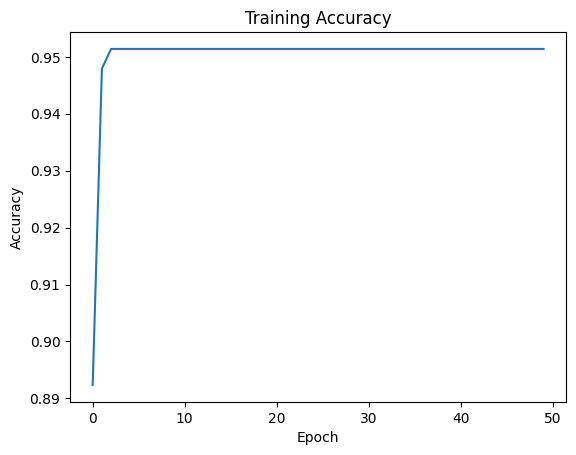

In [95]:
plt.plot(history.history["accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.show()

In [96]:
Dense(8, activation="relu")

<Dense name=dense_10, built=False>